In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

In [4]:
metadata = TrainingInfo.load_metadata()

In [5]:
from itertools import product

pull_dicts = {}

for SR_ensemble_mode, bin_ensemble_mode, bin_stats in product(["max", "mean"], ["max", "mean"], ["smeared", "fvt"]):
    if SR_ensemble_mode == "max":
        base_exp_name = "CR_fvt_training_ensemble_max"
    else:
        base_exp_name = "CR_fvt_training_ensemble_mean"
    fname = f"pull_by_hashes_{bin_stats}_{bin_ensemble_mode}_{base_exp_name}"
    pull_dicts[(SR_ensemble_mode, bin_ensemble_mode, bin_stats)] = pickle.load(open(f"./data/pulls/{fname}.pkl", "rb"))

In [6]:
for SR_ensemble_mode, bin_ensemble_mode, bin_stats in product(
    ["max", "mean"], ["max", "mean"], ["smeared", "fvt"]):
    for hash in pull_dicts[(SR_ensemble_mode, bin_ensemble_mode, bin_stats)]:
        hparams = metadata[hash]
        signal_ratio = hparams["dataset"]["signal_ratio"]
        SR_size = hparams["signal_region"]["4b_in_SR"]    
        sr_stats_hash = hparams["signal_region"]["SR_stats_hashes"][0]
        sr_stats_type = hparams["signal_region"]["stats_type"]
        if sr_stats_type == "fvt":
            noise_scale = np.inf
        else:
            noise_scale = metadata[sr_stats_hash]["smearing"]["noise_scale"]
        
        for v in pull_dicts[(SR_ensemble_mode, bin_ensemble_mode, bin_stats)][hash]:
            binning_mode = v["binning_mode"]
            nbins = v["nbins"]
            hists = v["hists"]
            hist_3b_rw = hists["3b_rw"]
            hist_3b_rw_sq = hists["3b_rw_sq"]
            hist_4b = hists["4b"]
            hist_4b_sq = hists["4b_sq"]
            var_o1 = hists["var_o1"]
            var_o2 = hists["var_o2"]
            hist_3b_o1 = hists["3b_corrected_o1"]
            hist_3b_o2 = hists["3b_corrected_o2"]
            hist_signal = hists["signal"]
            hist_bg4b = hists["bg4b"]
            
            if binning_mode == "train":
                var_o0 = hist_4b_sq + hist_3b_rw_sq
            else:
                var_o0 = hist_4b_sq + hist_3b_rw_sq / nbins**2

            v["signal_ratio"] = signal_ratio
            v["SR_size"] = SR_size
            v["noise_scale"] = noise_scale
            v["pull_o0"] = (hist_4b - hist_3b_rw) / np.sqrt(var_o0)
            v["pull_o1"] = (hist_4b - hist_3b_o1) / np.sqrt(var_o1)
            v["pull_o2"] = (hist_4b - hist_3b_o2) / np.sqrt(var_o2)
            v["pull_signal"] = hist_signal / np.sqrt(var_o0)
            v["pull_bg4b"] = (hist_bg4b - hist_3b_rw) / np.sqrt(var_o0)
            v["bin_ensemble_mode"] = bin_ensemble_mode
            v["bin_stats"] = bin_stats
            v["SR_ensemble_mode"] = SR_ensemble_mode

/tmp/ipykernel_3875516/2389542840.py:37: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_3875516/2389542840.py:40: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_3875516/2389542840.py:41: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_3875516/2389542840.py:38: RuntimeWarning:

invalid value encountered in divide

/tmp/ipykernel_3875516/2389542840.py:39: RuntimeWarning:

invalid value encountered in divide



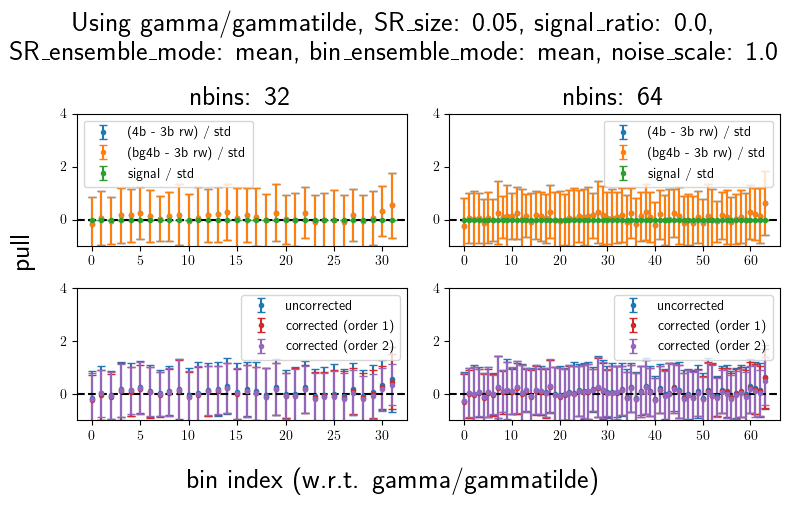

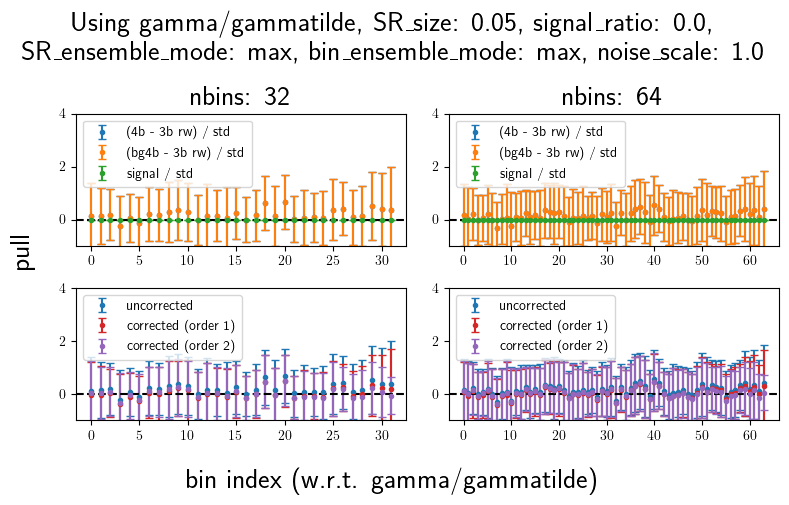

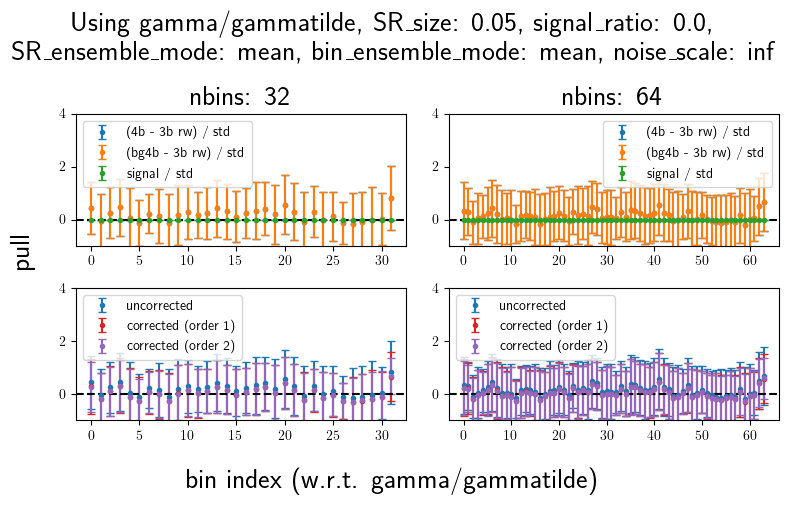

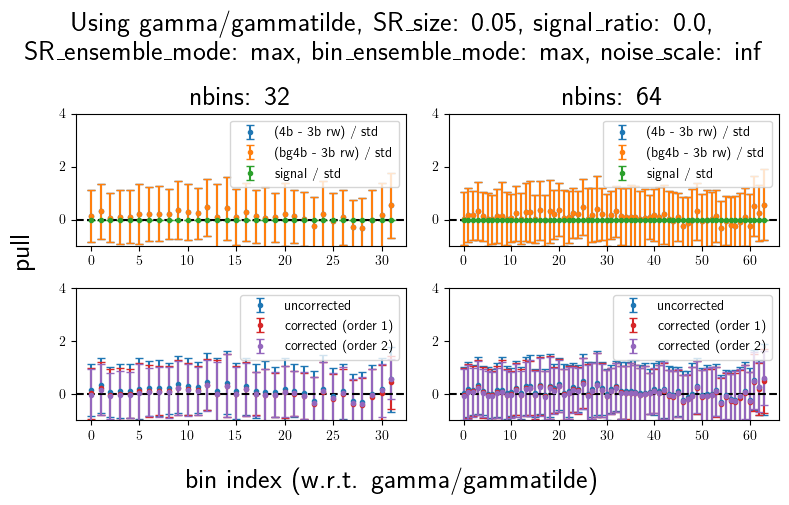

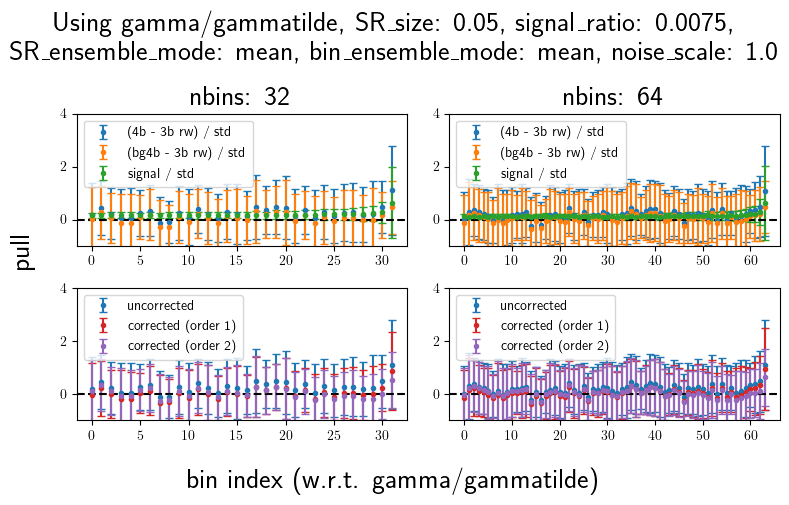

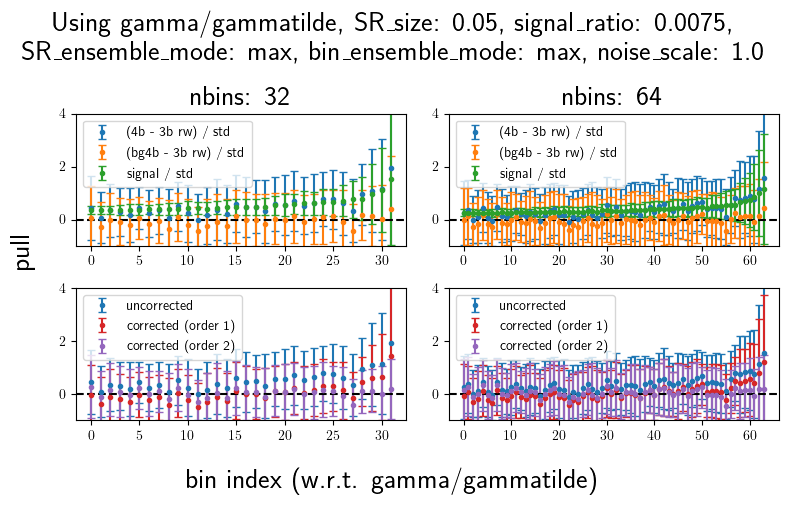

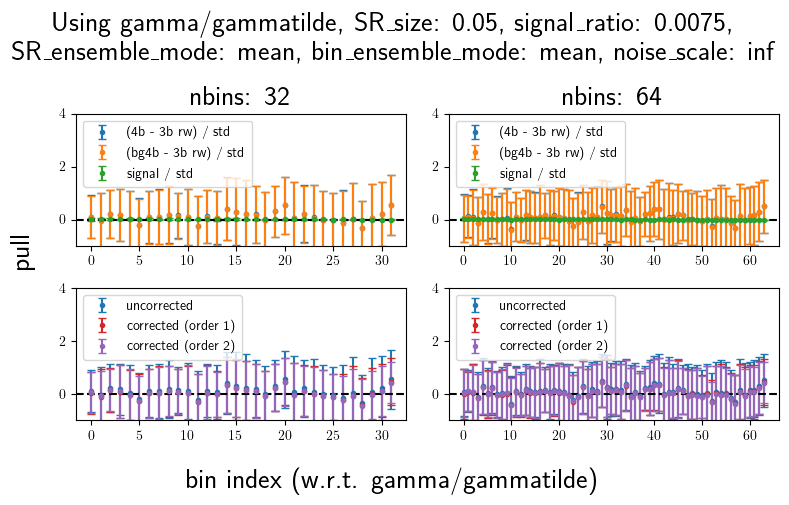

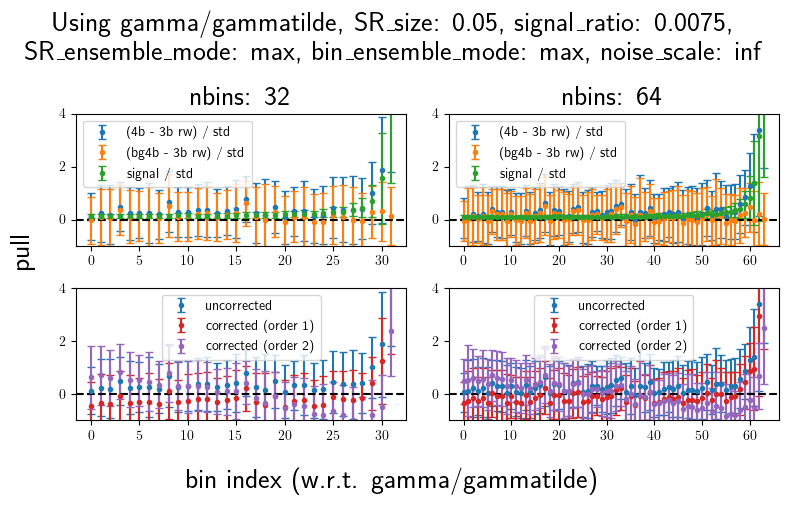

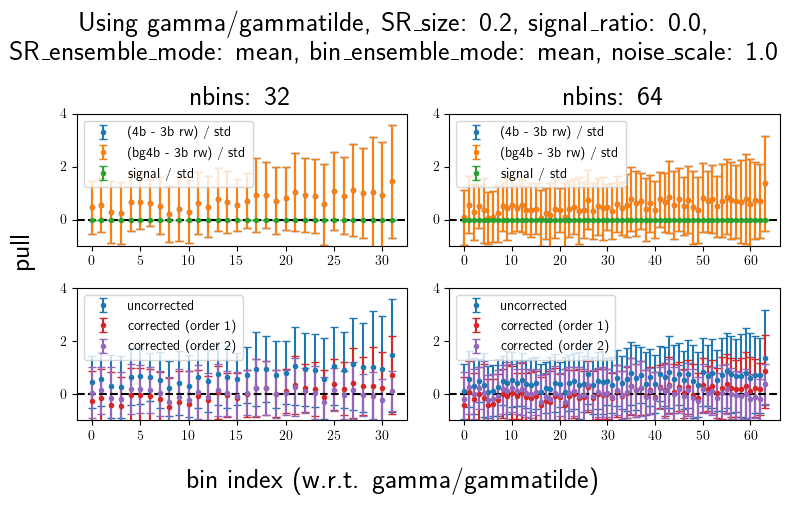

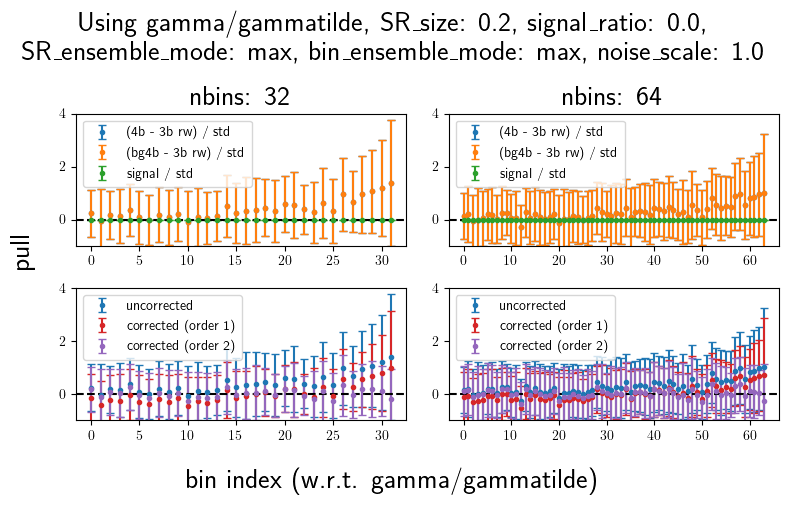

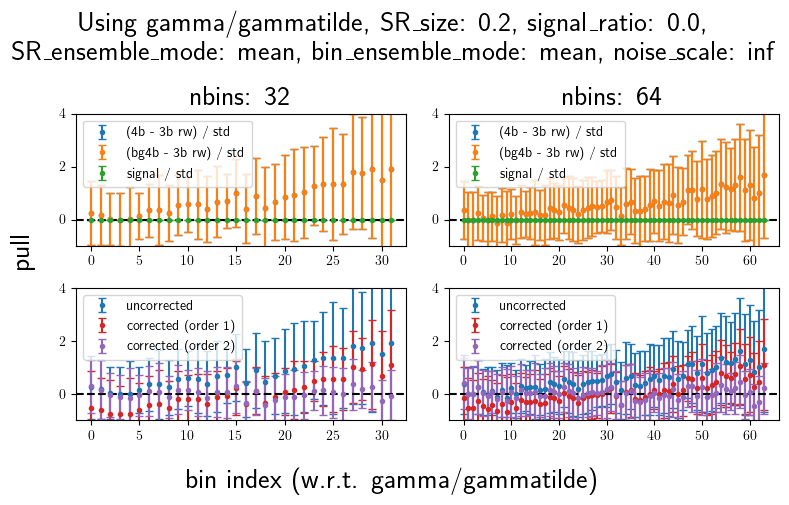

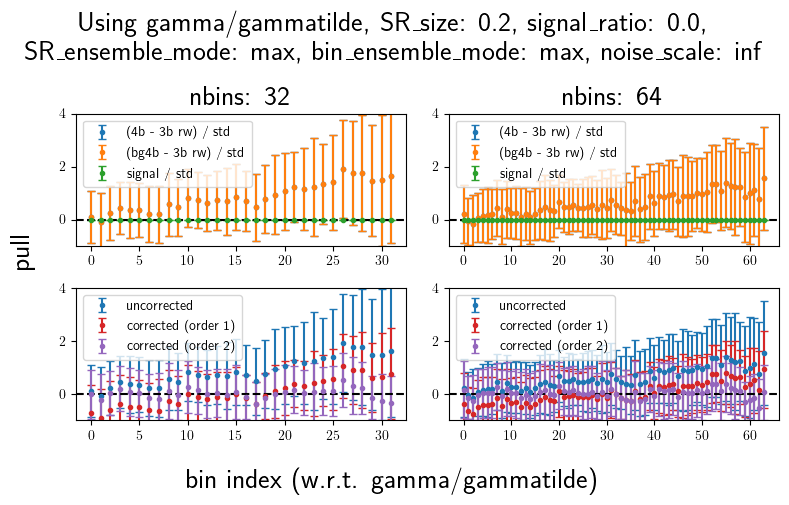

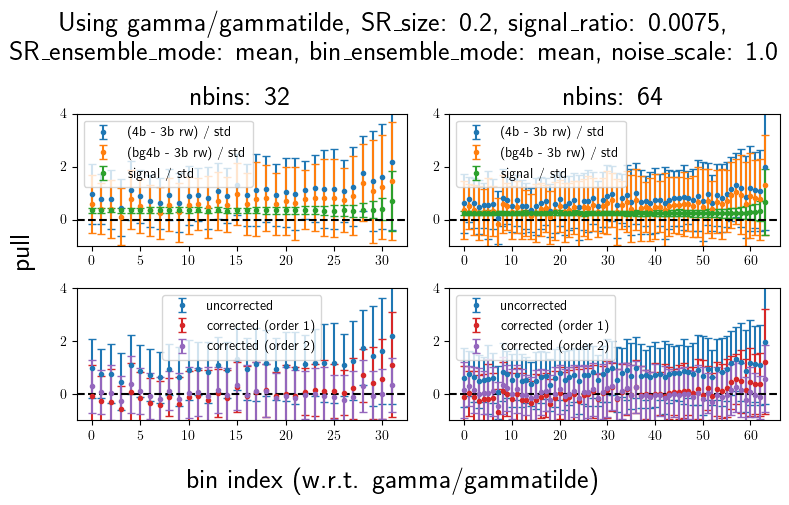

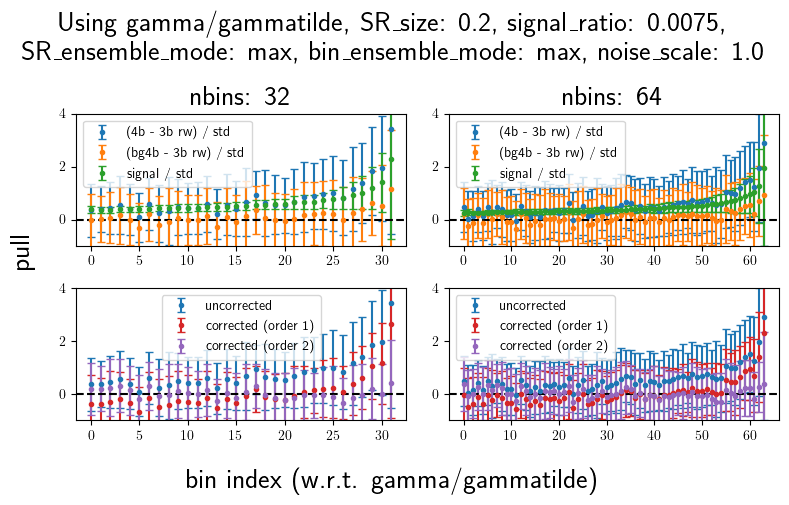

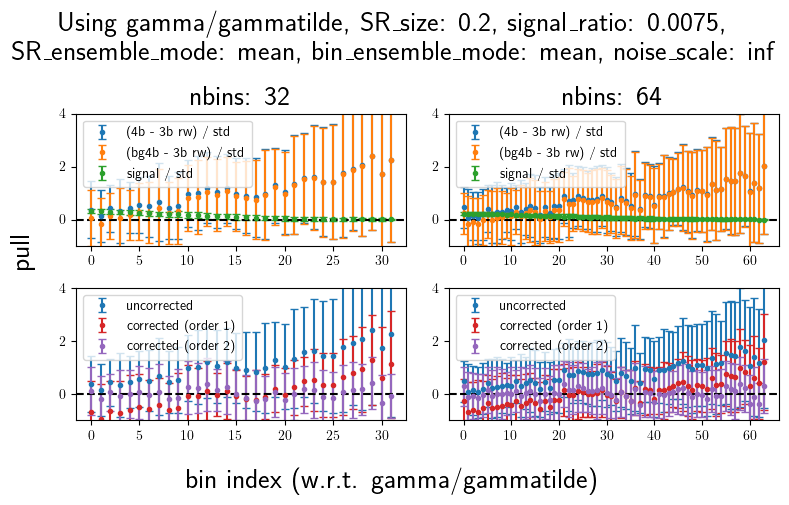

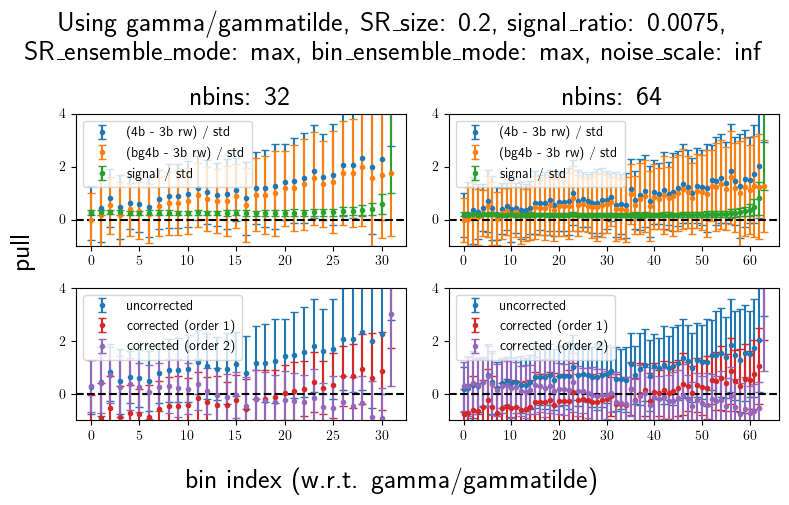

In [34]:
nbins_list = [32, 64]
colors = plt.get_cmap("tab10").colors

for SR_size, signal_ratio, noise_scale in product(
    [0.05, 0.2],
    [0.0, 0.0075],
    [1.0, np.inf]
):
    for SR_ensemble_mode, bin_ensemble_mode in [("mean", "mean"), ("max", "max")]:
        fig, ax = plt.subplots(2, len(nbins_list), figsize=(len(nbins_list) * 4, 5))
        fig.suptitle(f"Using gamma/gammatilde, SR_size: {SR_size}, signal_ratio: {signal_ratio}, \nSR_ensemble_mode: {SR_ensemble_mode}, bin_ensemble_mode: {bin_ensemble_mode}, noise_scale: {noise_scale}")
        fig.supxlabel("bin index (w.r.t. gamma/gammatilde)")
        fig.supylabel("pull")
        pull_dict_gen = (v for pull_dict in pull_dicts.values() for v_list in pull_dict.values() for v in v_list)

        tmp_dicts_target = [v for v in pull_dict_gen if v["SR_size"] == SR_size 
                    and v["signal_ratio"] == signal_ratio
                    and v["binning_mode"] == "train"
                    and v["noise_scale"] == noise_scale
                    and v["bin_ensemble_mode"] == bin_ensemble_mode
                    and v["SR_ensemble_mode"] == SR_ensemble_mode
                    and v["bin_stats"] == "smeared"]
        
        for nbins, ax_idx in zip(nbins_list, range(len(nbins_list))):
            tmp_dicts = [v for v in tmp_dicts_target if v["nbins"] == nbins]
            
            pull_signal_mean = np.mean([v["pull_signal"] for v in tmp_dicts], axis=0)
            pull_signal_std = np.std([v["pull_signal"] for v in tmp_dicts], axis=0)
            
            pull_bg4b_mean = np.mean([v["pull_bg4b"] for v in tmp_dicts], axis=0)
            pull_bg4b_std = np.std([v["pull_bg4b"] for v in tmp_dicts], axis=0)
            
            pull_mean = np.mean([v["pull_o0"] for v in tmp_dicts], axis=0)
            pull_std = np.std([v["pull_o0"] for v in tmp_dicts], axis=0)
            
            pull_mean_corrected_1 = np.mean([v["pull_o1"] for v in tmp_dicts], axis=0)
            pull_std_corrected_1 = np.std([v["pull_o1"] for v in tmp_dicts], axis=0)
            
            pull_mean_corrected_2 = np.mean([v["pull_o2"] for v in tmp_dicts], axis=0)
            pull_std_corrected_2 = np.std([v["pull_o2"] for v in tmp_dicts], axis=0)
            
            
            current_ax_0 = ax[0, ax_idx]
            current_ax_0.set_title(f"nbins: {nbins}")
            bins = np.arange(nbins)
            current_ax_0.errorbar(bins, pull_mean, yerr=pull_std, label="(4b - 3b rw) / std", capsize=3, fmt="o")
            current_ax_0.errorbar(bins, pull_bg4b_mean, yerr=pull_bg4b_std, label="(bg4b - 3b rw) / std", capsize=3, fmt="o", 
                                color=plt.get_cmap("tab10").colors[1])
            current_ax_0.errorbar(bins, pull_signal_mean, yerr=pull_signal_std, label="signal / std", capsize=3, fmt="o", 
                                color=plt.get_cmap("tab10").colors[2])
            current_ax_0.axhline(0, color="black", linestyle="--")
            current_ax_0.legend()
            current_ax_0.set_ylim(-1, 4)
            
            current_ax_1 = ax[1, ax_idx]
            current_ax_1.errorbar(bins, pull_mean, yerr=pull_std, label="uncorrected", capsize=3, fmt="o", 
                                color=plt.get_cmap("tab10").colors[0])
            current_ax_1.errorbar(bins, pull_mean_corrected_1, yerr=pull_std_corrected_1, label="corrected (order 1)", capsize=3, fmt="o", 
                                color=plt.get_cmap("tab10").colors[3])
            current_ax_1.errorbar(bins, pull_mean_corrected_2, yerr=pull_std_corrected_2, label="corrected (order 2)", capsize=3, fmt="o", 
                                color=plt.get_cmap("tab10").colors[4])
            current_ax_1.axhline(0, color="black", linestyle="--")
            current_ax_1.legend()
            current_ax_1.set_ylim(-1, 4)
            
        plt.tight_layout()
        plt.show()
        


In [7]:
v_gen = (v for pull_dict in pull_dicts.values() for v_list in pull_dict.values() for v in v_list)

pull_df = pd.DataFrame([
    {"mean_pull_o0": np.sqrt(np.mean(v["pull_o0"]**2)), 
    "mean_pull_o1": np.sqrt(np.mean(v["pull_o1"]**2)), 
    "mean_pull_o2": np.sqrt(np.mean(v["pull_o2"]**2)), 
    "binning_mode": v["binning_mode"],
    "nbins": v["nbins"], 
    "SR_size": v["SR_size"], 
    "signal_ratio": v["signal_ratio"], 
    "noise_scale": v["noise_scale"], 
    "SR_ensemble_mode": v["SR_ensemble_mode"],
    "bin_ensemble_mode": v["bin_ensemble_mode"], 
    "bin_stats": v["bin_stats"]} for v in v_gen])

from scipy.stats import chi2
sig_level = 0.05
pull_df["rej_o0"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"]) / pull_df["nbins"])**0.5
pull_df["rej_o1"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 1) / pull_df["nbins"])**0.5
pull_df["rej_o2"] = (chi2.ppf(1 - sig_level, df=pull_df["nbins"] - 2) / pull_df["nbins"])**0.5
pull_df["rejected_o0"] = pull_df["mean_pull_o0"] > pull_df["rej_o0"]
pull_df["rejected_o1"] = pull_df["mean_pull_o1"] > pull_df["rej_o1"]
pull_df["rejected_o2"] = pull_df["mean_pull_o2"] > pull_df["rej_o2"]
pull_df_summary = pull_df.groupby(["SR_size", "signal_ratio", "nbins", "SR_ensemble_mode", "bin_ensemble_mode",
                                   "binning_mode", "noise_scale", "bin_stats"]).mean().reset_index()

In [13]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Define parameters
noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
bin_stats = "smeared"
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # Plotly default colors
line_styles = ["dash", "solid"]  # Plotly line styles

# For each nbins and binning_mode combination
nbins = 64
binning_mode = "train"

for correction_order, label in [
    ("rejected_o0", "order: 0"), 
    ("rejected_o1", "order: 1"), 
    ("rejected_o2", "order: 2")
]:
    # Create a 2x2 subplot figure with updated spacing
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[f"SR_size: {SR_size}" for SR_size in [0.05, 0.1, 0.15, 0.2]],
        shared_xaxes=True,
        shared_yaxes=True,
        vertical_spacing=0.15,
        horizontal_spacing=0.15
    )
    
    # Add a main title with tight layout
    fig.update_layout(
        title=f"Smearing vs. FvT, ensemble: {bin_ensemble_mode}, nbins: {nbins}, binning: {binning_mode}, correction {label}",
        height=700,
        width=1000,
        margin=dict(l=50, r=50, t=80, b=120, pad=0),
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.15,
            xanchor="center",
            x=0.5
        )
    )
    
    # Plot for each SR_size
    for i, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        row = i // 2 + 1
        col = i % 2 + 1
        
        # Add a horizontal line for significance level
        sig_level_trace = go.Scatter(
            x=[0, 0.02],
            y=[sig_level, sig_level],
            mode='lines',
            line=dict(color='red', dash='solid', width=1),
            name='sig_level',
            legendgroup='sig_level',
            showlegend=(i==0)
        )
        fig.add_trace(sig_level_trace, row=row, col=col)
        
        # Add traces for each noise scale and ensemble mode
        for j, noise_scale in enumerate(noise_scales):
            # Filter data for current parameters
            pull_df_filtered = pull_df_summary[
                (pull_df_summary["SR_size"] == SR_size) &
                (pull_df_summary["nbins"] == nbins) &
                (pull_df_summary["binning_mode"] == binning_mode) &
                (pull_df_summary["noise_scale"] == noise_scale) &
                # (pull_df_summary["bin_ensemble_mode"] == bin_ensemble_mode) &
                # (pull_df_summary["SR_ensemble_mode"] == SR_ensemble_mode) &
                (pull_df_summary["bin_stats"] == bin_stats)
            ]
            
            if not pull_df_filtered.empty:
                mean_df = pull_df_filtered[(pull_df_filtered["bin_ensemble_mode"] == "mean")
                                           & (pull_df_filtered["SR_ensemble_mode"] == "mean")]
                if not mean_df.empty:
                    mean_trace = go.Scatter(
                        x=mean_df["signal_ratio"],
                        y=mean_df[correction_order],
                        mode='lines+markers',
                        line=dict(color=colors[j], dash='dash', width=1),
                        marker=dict(size=4),
                        name=f"Noise={noise_scale} (mean)",
                        legendgroup=f"noise_{noise_scale}_mean",
                        showlegend=(i==0)
                    )
                    fig.add_trace(mean_trace, row=row, col=col)
                
                max_df = pull_df_filtered[(pull_df_filtered["bin_ensemble_mode"] == "max")
                                           & (pull_df_filtered["SR_ensemble_mode"] == "max")]
                if not max_df.empty:
                    max_trace = go.Scatter(
                        x=max_df["signal_ratio"],
                        y=max_df[correction_order],
                        mode='lines+markers',
                        line=dict(color=colors[j], dash='solid', width=1),
                        marker=dict(size=4),
                        name=f"Noise={noise_scale} (max)",
                        legendgroup=f"noise_{noise_scale}_max",
                        showlegend=(i==0)
                    )
                    fig.add_trace(max_trace, row=row, col=col)
    
    # Update axes labels
    fig.update_xaxes(title_text="Signal Ratio", range=[-0.002, 0.022])
    fig.update_yaxes(title_text="Rejection Rate", range=[0, 1.05])
    
    # Create custom legend traces for the ensemble modes (dash patterns)
    style_smeared_trace = go.Scatter(
        x=[None], y=[None],
        mode='lines',
        line=dict(color='black', dash='dash'),
        name='smeared',
        legendgroup='style_smeared',
        showlegend=True
    )
    fig.add_trace(style_smeared_trace)
    
    style_fvt_trace = go.Scatter(
        x=[None], y=[None],
        mode='lines',
        line=dict(color='black', dash='solid'),
        name='fvt',
        legendgroup='style_fvt',
        showlegend=True
    )
    fig.add_trace(style_fvt_trace)
    
    # Display the figure
    fig.show()

In [8]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Define parameters
noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
bin_stats = "smeared"
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # Plotly default colors
line_styles = ["dash", "solid"]  # Plotly line styles

# For each nbins and binning_mode combination
nbins = 128
binning_mode = "train"

for correction_order, label in [
    ("rejected_o0", "order: 0"), 
    ("rejected_o1", "order: 1"), 
    ("rejected_o2", "order: 2")
]:
    # Create a 2x2 subplot figure with updated spacing
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[f"SR_size: {SR_size}" for SR_size in [0.05, 0.1, 0.15, 0.2]],
        shared_xaxes=True,
        shared_yaxes=True,
        vertical_spacing=0.15,
        horizontal_spacing=0.15
    )
    
    # Add a main title with tight layout
    fig.update_layout(
        title=f"Smearing vs. FvT, ensemble: {bin_ensemble_mode}, nbins: {nbins}, binning: {binning_mode}, correction {label}",
        height=700,
        width=1000,
        margin=dict(l=50, r=50, t=80, b=120, pad=0),
        legend=dict(
            orientation="h",
            yanchor="top",
            y=-0.15,
            xanchor="center",
            x=0.5
        )
    )
    
    # Plot for each SR_size
    for i, SR_size in enumerate([0.05, 0.1, 0.15, 0.2]):
        row = i // 2 + 1
        col = i % 2 + 1
        
        # Add a horizontal line for significance level
        sig_level_trace = go.Scatter(
            x=[0, 0.02],
            y=[sig_level, sig_level],
            mode='lines',
            line=dict(color='red', dash='solid', width=1),
            name='sig_level',
            legendgroup='sig_level',
            showlegend=(i==0)
        )
        fig.add_trace(sig_level_trace, row=row, col=col)
        
        # Add traces for each noise scale and ensemble mode
        for j, noise_scale in enumerate(noise_scales):
            # Filter data for current parameters
            pull_df_filtered = pull_df_summary[
                (pull_df_summary["SR_size"] == SR_size) &
                (pull_df_summary["nbins"] == nbins) &
                (pull_df_summary["binning_mode"] == binning_mode) &
                (pull_df_summary["noise_scale"] == noise_scale) &
                # (pull_df_summary["bin_ensemble_mode"] == bin_ensemble_mode) &
                # (pull_df_summary["SR_ensemble_mode"] == SR_ensemble_mode) &
                (pull_df_summary["bin_stats"] == bin_stats)
            ]
            
            if not pull_df_filtered.empty:
                mean_df = pull_df_filtered[(pull_df_filtered["bin_ensemble_mode"] == "mean")
                                           & (pull_df_filtered["SR_ensemble_mode"] == "mean")]
                if not mean_df.empty:
                    mean_trace = go.Scatter(
                        x=mean_df["signal_ratio"],
                        y=mean_df[correction_order],
                        mode='lines+markers',
                        line=dict(color=colors[j], dash='dash', width=1),
                        marker=dict(size=4),
                        name=f"Noise={noise_scale} (mean)",
                        legendgroup=f"noise_{noise_scale}_mean",
                        showlegend=(i==0)
                    )
                    fig.add_trace(mean_trace, row=row, col=col)
                
                max_df = pull_df_filtered[(pull_df_filtered["bin_ensemble_mode"] == "max")
                                           & (pull_df_filtered["SR_ensemble_mode"] == "max")]
                if not max_df.empty:
                    max_trace = go.Scatter(
                        x=max_df["signal_ratio"],
                        y=max_df[correction_order],
                        mode='lines+markers',
                        line=dict(color=colors[j], dash='solid', width=1),
                        marker=dict(size=4),
                        name=f"Noise={noise_scale} (max)",
                        legendgroup=f"noise_{noise_scale}_max",
                        showlegend=(i==0)
                    )
                    fig.add_trace(max_trace, row=row, col=col)
    
    # Update axes labels
    fig.update_xaxes(title_text="Signal Ratio", range=[-0.002, 0.022])
    fig.update_yaxes(title_text="Rejection Rate", range=[0, 1.05])
    
    # Create custom legend traces for the ensemble modes (dash patterns)
    style_smeared_trace = go.Scatter(
        x=[None], y=[None],
        mode='lines',
        line=dict(color='black', dash='dash'),
        name='smeared',
        legendgroup='style_smeared',
        showlegend=True
    )
    fig.add_trace(style_smeared_trace)
    
    style_fvt_trace = go.Scatter(
        x=[None], y=[None],
        mode='lines',
        line=dict(color='black', dash='solid'),
        name='fvt',
        legendgroup='style_fvt',
        showlegend=True
    )
    fig.add_trace(style_fvt_trace)
    
    # Display the figure
    fig.show()

In [16]:
thrs = 0.06

calibrated_pairs_o0 = []
calibrated_pairs_o1 = []
calibrated_pairs_o2 = []

pull_df_summary_reindex = pull_df_summary.set_index([
    "SR_ensemble_mode", "bin_ensemble_mode", "bin_stats", "noise_scale", 
    "nbins", "binning_mode", "SR_size"]).sort_index()
possible_combs = pull_df_summary[["SR_ensemble_mode", "bin_ensemble_mode", "bin_stats", "noise_scale", 
                                                     "nbins", "binning_mode", "SR_size"]].drop_duplicates().values
possible_combs = [tuple(x) for x in possible_combs]
for idx in possible_combs:
    SR_ensemble_mode, bin_ensemble_mode, bin_stats, noise_scale, nbins, binning_mode, SR_size = idx
    df_tmp = pull_df_summary_reindex.loc[pull_df_summary_reindex["signal_ratio"] == 0.0]
    if idx not in df_tmp.index:
        continue
    df_tmp = df_tmp.loc[idx]
    dc_tmp = {
        "SR_ensemble_mode": SR_ensemble_mode,
        "bin_ensemble_mode": bin_ensemble_mode, 
        "bin_stats": bin_stats, 
        "noise_scale": noise_scale,
        "nbins": nbins, 
        "binning_mode": binning_mode, 
              "SR_size": SR_size}
    if df_tmp["rejected_o0"] <= thrs:
        calibrated_pairs_o0.append(dc_tmp)
    if df_tmp["rejected_o1"] <= thrs:
        calibrated_pairs_o1.append(dc_tmp)
    if df_tmp["rejected_o2"] <= thrs:
        calibrated_pairs_o2.append(dc_tmp)
        
calibrated_pairs_o0 = pd.DataFrame(calibrated_pairs_o0).sort_index()
calibrated_pairs_o1 = pd.DataFrame(calibrated_pairs_o1).sort_index()
calibrated_pairs_o2 = pd.DataFrame(calibrated_pairs_o2).sort_index()

In [17]:
print("Calibrated without correction")
display(calibrated_pairs_o0)
idx_tuples = [tuple(x) for x in calibrated_pairs_o0.values]
for t in idx_tuples:
    display(pull_df_summary_reindex.loc[t, ["signal_ratio", "rejected_o0", "rejected_o1", "rejected_o2"]])

Calibrated without correction


,SR_ensemble_mode,bin_ensemble_mode,bin_stats,noise_scale,nbins,binning_mode,SR_size
0,mean,mean,smeared,2.0,64,train,0.05
1,max,max,smeared,2.0,256,train,0.05
2,max,mean,smeared,0.5,256,train,0.05
3,max,mean,smeared,2.0,256,train,0.05
4,max,mean,smeared,3.0,256,train,0.05
5,mean,max,fvt,2.0,256,train,0.05
6,mean,mean,fvt,1.0,256,train,0.05
7,max,max,smeared,2.0,128,train,0.10
8,max,max,smeared,2.0,256,train,0.15


signal_ratio  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
mean             mean              smeared   2.0         64    train        0.05           0.0000   
                                                                            0.05           0.0050   
                                                                            0.05           0.0075   
                                                                            0.05           0.0100   
                                                                            0.05           0.0200   

                                                                                     rejected_o0  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
mean             mean              smeared   2.0         64    train        0.05            0.06   
                                                                            0.05            0.12   
                                                                            0.05            0.18   
                                                                            0.05            0.96   
                                                                            0.05            1.00   

                                                                                     rejected_o1  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
mean             mean              smeared   2.0         64    train        0.05            0.02   
                                                                            0.05            0.06   
                                                                            0.05            0.08   
                                                                            0.05            0.94   
                                                                            0.05            1.00   

                                                                                     rejected_o2  
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
mean             mean              smeared   2.0         64    train        0.05            0.02  
                                                                            0.05            0.06  
                                                                            0.05            0.02  
                                                                            0.05            0.92  
                                                                            0.05            0.98

signal_ratio  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
max              max               smeared   2.0         256   train        0.05           0.0000   
                                                                            0.05           0.0050   
                                                                            0.05           0.0075   
                                                                            0.05           0.0100   
                                                                            0.05           0.0200   

                                                                                     rejected_o0  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max              max               smeared   2.0         256   train        0.05            0.06   
                                                                            0.05            0.16   
                                                                            0.05            0.44   
                                                                            0.05            0.98   
                                                                            0.05            1.00   

                                                                                     rejected_o1  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max              max               smeared   2.0         256   train        0.05            0.04   
                                                                            0.05            0.12   
                                                                            0.05            0.40   
                                                                            0.05            0.98   
                                                                            0.05            1.00   

                                                                                     rejected_o2  
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
max              max               smeared   2.0         256   train        0.05            0.02  
                                                                            0.05            0.10  
                                                                            0.05            0.14  
                                                                            0.05            0.64  
                                                                            0.05            0.86

signal_ratio  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
max              mean              smeared   0.5         256   train        0.05           0.0000   
                                                                            0.05           0.0050   
                                                                            0.05           0.0075   
                                                                            0.05           0.0100   
                                                                            0.05           0.0200   

                                                                                     rejected_o0  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max              mean              smeared   0.5         256   train        0.05            0.04   
                                                                            0.05            0.22   
                                                                            0.05            0.40   
                                                                            0.05            0.90   
                                                                            0.05            1.00   

                                                                                     rejected_o1  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max              mean              smeared   0.5         256   train        0.05            0.02   
                                                                            0.05            0.18   
                                                                            0.05            0.26   
                                                                            0.05            0.90   
                                                                            0.05            1.00   

                                                                                     rejected_o2  
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
max              mean              smeared   0.5         256   train        0.05            0.00  
                                                                            0.05            0.10  
                                                                            0.05            0.06  
                                                                            0.05            0.80  
                                                                            0.05            0.98

...

signal_ratio  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
max              mean              smeared   3.0         256   train        0.05           0.0000   
                                                                            0.05           0.0050   
                                                                            0.05           0.0075   
                                                                            0.05           0.0100   
                                                                            0.05           0.0200   

                                                                                     rejected_o0  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max              mean              smeared   3.0         256   train        0.05            0.06   
                                                                            0.05            0.16   
                                                                            0.05            0.66   
                                                                            0.05            1.00   
                                                                            0.05            0.98   

                                                                                     rejected_o1  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max              mean              smeared   3.0         256   train        0.05            0.08   
                                                                            0.05            0.12   
                                                                            0.05            0.52   
                                                                            0.05            1.00   
                                                                            0.05            0.98   

                                                                                     rejected_o2  
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
max              mean              smeared   3.0         256   train        0.05            0.08  
                                                                            0.05            0.10  
                                                                            0.05            0.36  
                                                                            0.05            0.98  
                                                                            0.05            0.98

signal_ratio  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
mean             max               fvt       2.0         256   train        0.05           0.0000   
                                                                            0.05           0.0050   
                                                                            0.05           0.0075   
                                                                            0.05           0.0100   
                                                                            0.05           0.0200   

                                                                                     rejected_o0  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
mean             max               fvt       2.0         256   train        0.05            0.06   
                                                                            0.05            0.02   
                                                                            0.05            0.32   
                                                                            0.05            1.00   
                                                                            0.05            1.00   

                                                                                     rejected_o1  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
mean             max               fvt       2.0         256   train        0.05            0.04   
                                                                            0.05            0.02   
                                                                            0.05            0.26   
                                                                            0.05            1.00   
                                                                            0.05            1.00   

                                                                                     rejected_o2  
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
mean             max               fvt       2.0         256   train        0.05            0.04  
                                                                            0.05            0.02  
                                                                            0.05            0.20  
                                                                            0.05            0.90  
                                                                            0.05            0.96

signal_ratio  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
mean             mean              fvt       1.0         256   train        0.05           0.0000   
                                                                            0.05           0.0050   
                                                                            0.05           0.0075   
                                                                            0.05           0.0100   
                                                                            0.05           0.0200   

                                                                                     rejected_o0  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
mean             mean              fvt       1.0         256   train        0.05            0.06   
                                                                            0.05            0.14   
                                                                            0.05            0.32   
                                                                            0.05            0.92   
                                                                            0.05            0.98   

                                                                                     rejected_o1  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
mean             mean              fvt       1.0         256   train        0.05            0.08   
                                                                            0.05            0.16   
                                                                            0.05            0.28   
                                                                            0.05            0.84   
                                                                            0.05            0.98   

                                                                                     rejected_o2  
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
mean             mean              fvt       1.0         256   train        0.05            0.06  
                                                                            0.05            0.10  
                                                                            0.05            0.22  
                                                                            0.05            0.84  
                                                                            0.05            0.98

signal_ratio  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
max              max               smeared   2.0         128   train        0.1            0.0000   
                                                                            0.1            0.0050   
                                                                            0.1            0.0075   
                                                                            0.1            0.0100   
                                                                            0.1            0.0200   

                                                                                     rejected_o0  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max              max               smeared   2.0         128   train        0.1             0.06   
                                                                            0.1             0.16   
                                                                            0.1             0.50   
                                                                            0.1             0.98   
                                                                            0.1             1.00   

                                                                                     rejected_o1  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max              max               smeared   2.0         128   train        0.1             0.02   
                                                                            0.1             0.10   
                                                                            0.1             0.34   
                                                                            0.1             0.98   
                                                                            0.1             1.00   

                                                                                     rejected_o2  
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
max              max               smeared   2.0         128   train        0.1             0.00  
                                                                            0.1             0.08  
                                                                            0.1             0.22  
                                                                            0.1             0.92  
                                                                            0.1             1.00

signal_ratio  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                 
max              max               smeared   2.0         256   train        0.15           0.0000   
                                                                            0.15           0.0050   
                                                                            0.15           0.0075   
                                                                            0.15           0.0100   
                                                                            0.15           0.0200   

                                                                                     rejected_o0  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max              max               smeared   2.0         256   train        0.15            0.04   
                                                                            0.15            0.24   
                                                                            0.15            0.54   
                                                                            0.15            0.98   
                                                                            0.15            1.00   

                                                                                     rejected_o1  \
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size                
max              max               smeared   2.0         256   train        0.15            0.02   
                                                                            0.15            0.08   
                                                                            0.15            0.34   
                                                                            0.15            0.98   
                                                                            0.15            1.00   

                                                                                     rejected_o2  
SR_ensemble_mode bin_ensemble_mode bin_stats noise_scale nbins binning_mode SR_size               
max              max               smeared   2.0         256   train        0.15            0.02  
                                                                            0.15            0.06  
                                                                            0.15            0.20  
                                                                            0.15            0.96  
                                                                            0.15            1.00

In [27]:
SR_size = 0.05
signal_ratio = 0.0
cols = ["SR_size", "bin_stats", "noise_scale", "SR_ensemble_mode", "bin_ensemble_mode", "binning_mode", "nbins", 
        "rejected_o0", "rejected_o1", "rejected_o2"]

print("Using mean of gamma / gamma tilde")
display(pull_df_summary.loc[(
    (pull_df_summary["signal_ratio"] == signal_ratio) 
    & (pull_df_summary["SR_size"] == SR_size) 
    & (pull_df_summary["bin_stats"] == "smeared")
    & (pull_df_summary["SR_ensemble_mode"] == "mean")
    & (pull_df_summary["bin_ensemble_mode"] == "mean")
    & (pull_df_summary["binning_mode"] == "train")
    & (np.isin(pull_df_summary["nbins"], [64, 128]))), 
    cols])


print("Using max of gamma / gamma tilde")
display(pull_df_summary.loc[(
    (pull_df_summary["signal_ratio"] == signal_ratio) 
    & (pull_df_summary["SR_size"] == SR_size) 
    & (pull_df_summary["bin_stats"] == "smeared")
    & (pull_df_summary["SR_ensemble_mode"] == "max")
    & (pull_df_summary["bin_ensemble_mode"] == "max")
    & (pull_df_summary["binning_mode"] == "train")
    & (np.isin(pull_df_summary["nbins"], [64, 128]))), 
    cols])

Using mean of gamma / gamma tilde


,SR_size,bin_stats,noise_scale,SR_ensemble_mode,bin_ensemble_mode,binning_mode,nbins,rejected_o0,rejected_o1,rejected_o2
391,0.05,smeared,0.5,mean,mean,train,64,0.16,0.06,0.04
393,0.05,smeared,1.0,mean,mean,train,64,0.14,0.02,0.02
395,0.05,smeared,2.0,mean,mean,train,64,0.06,0.02,0.02
397,0.05,smeared,3.0,mean,mean,train,64,0.12,0.06,0.04
399,0.05,smeared,inf,mean,mean,train,64,0.14,0.04,0.04
471,0.05,smeared,0.5,mean,mean,train,128,0.14,0.10,0.06
473,0.05,smeared,1.0,mean,mean,train,128,0.12,0.02,0.04
475,0.05,smeared,2.0,mean,mean,train,128,0.12,0.04,0.04
477,0.05,smeared,3.0,mean,mean,train,128,0.12,0.04,0.04
479,0.05,smeared,inf,mean,mean,train,128,0.18,0.10,0.10


Using max of gamma / gamma tilde


,SR_size,bin_stats,noise_scale,SR_ensemble_mode,bin_ensemble_mode,binning_mode,nbins,rejected_o0,rejected_o1,rejected_o2
331,0.05,smeared,0.5,max,max,train,64,0.08,0.04,0.04
333,0.05,smeared,1.0,max,max,train,64,0.12,0.06,0.04
335,0.05,smeared,2.0,max,max,train,64,0.08,0.04,0.02
337,0.05,smeared,3.0,max,max,train,64,0.14,0.08,0.06
339,0.05,smeared,inf,max,max,train,64,0.20,0.08,0.10
411,0.05,smeared,0.5,max,max,train,128,0.12,0.06,0.04
413,0.05,smeared,1.0,max,max,train,128,0.08,0.04,0.02
415,0.05,smeared,2.0,max,max,train,128,0.10,0.04,0.02
417,0.05,smeared,3.0,max,max,train,128,0.10,0.04,0.06
419,0.05,smeared,inf,max,max,train,128,0.16,0.08,0.08
